# This code obtaines figures for analyzying the trained LSTM

## Victoria Knapp Perez and Jason LaRuez

In [1]:
! pip install -Uqq fastbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.5 MB/s eta 0:00:00


In [12]:
import fastbook

# Importing data
import kagglehub
import os
import json


import matplotlib.pyplot as plt # Plotting
import pandas as pd # Pandas dataframes

from fastbook import *
from fastai.text.all import *
import torch


from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback #early stopper
from fastai.callback.rnn import RNNRegularizer #Regulariza RNN
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix #Analytics tools
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay


In [3]:
from google.colab import drive
drive.mount('/content/drive')

out_dir = '/content/drive/MyDrive/NLPforFakeNews'
os.makedirs(out_dir, exist_ok=True)



Mounted at /content/drive


In [4]:
proc_dir = os.path.join(out_dir, "processed_datasets")
os.makedirs(proc_dir, exist_ok=True)

train_path = os.path.join(proc_dir, "train_FvT.csv")
val_path   = os.path.join(proc_dir, "val_FvT.csv")
test_path  = os.path.join(proc_dir, "test_FvT.csv")

# Read the datasets
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

In [5]:

# Combine training and validation dataset for dataloader and learner
df_combined = pd.concat([train_df, val_df], ignore_index=True)
valid_idx = range(len(train_df), len(df_combined))

# Load the LLM

In [6]:

#Relabel columns
df_combined = df_combined.rename(columns={'text_full':'text'})
df_combined['text']  = df_combined['text'].astype(str)
df_combined['label'] = df_combined['label'].astype(str).str.strip()


# Text block for LM
tb_lm = TextBlock.from_df(
    'text',
    is_lm=True,
    seq_len=80
)

#  DataBlock with explicit IndexSplitter
dblock_lm = DataBlock(
    blocks=tb_lm,                      # only X for LM; Y is auto-shifted
    get_x=ColReader('text'),
    splitter=IndexSplitter(valid_idx)
)

# Build LM DataLoaders
dls_lm = dblock_lm.dataloaders(
    df_combined,
    bs=128
)

dblock = DataBlock(
    blocks=(
        TextBlock.from_df(text_cols='text', seq_len=72, vocab=dls_lm.vocab),
        CategoryBlock()
    ),
    get_x=ColReader('text'),
    get_y=ColReader('label'),
    splitter=IndexSplitter(valid_idx)
) #Datablock for loading train and val sets

dls_clas = dblock.dataloaders(df_combined, bs=64) #Load train and val sets


learn = text_classifier_learner(
    dls_clas, AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy,
    loss_func=CrossEntropyLossFlat()
) #Learner

# Load the finetuned encoder

learn.path = Path(out_dir) / 'LSTM_parameters'
learn.path.mkdir(parents=True, exist_ok=True)  # make sure it exists


learn.model_dir = '.'
learn.load_encoder('finetuned')
learn.load('class')


In [7]:
#Calculate test df accuracy
texts  = test_df['text_full'].astype(str).tolist()
test_dl = learn.dls.test_dl(texts)


y_idx = test_df['label']

preds = learn.get_preds(dl=test_dl)



from sklearn.metrics import accuracy_score

y_hat = preds[0].argmax(dim=1)

acc = accuracy_score(y_idx, y_hat)
print(f"\n Test accuracy. : {acc:.3f}\n")


 Test accuracy. : 0.996



# Confusion matrix

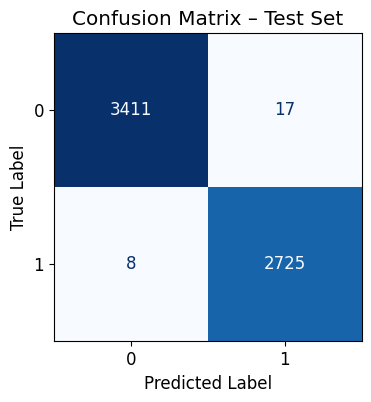

In [11]:
cm = confusion_matrix(y_idx, y_hat)
labels_sorted = learn.dls.vocab[1]  # category names from dataloader

#Plot
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Confusion Matrix – Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)

img_dir = Path(out_dir) / "imgs"
os.makedirs(img_dir, exist_ok=True)
save_path = img_dir / "CM-LSTM.jpg"
plt.savefig(save_path, dpi=300, bbox_inches='tight')


plt.show()

# ROC curve

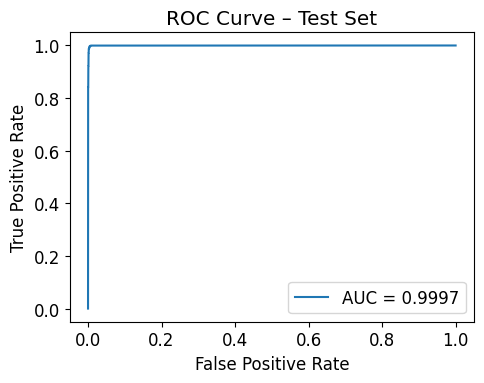

In [36]:
fpr, tpr, _ = roc_curve(y_idx, preds[0][:,1])
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
#plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Test Set')
plt.legend(loc='lower right')
plt.tight_layout()

img_dir = Path(out_dir) / "imgs"
os.makedirs(img_dir, exist_ok=True)
save_path = img_dir / "ROC-LSTM.jpg"
plt.savefig(save_path, dpi=300, bbox_inches='tight')



plt.show()